# Generating RBS Calculator Data and Validation
In  this notebook, we demonstrate sampling approaches to generating synthetic consignments from RBS calculator data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np


In [ ]:
datadir = Path("data/fake_pis_data.csv")    
df = pd.read_csv(datadir)
df = df.dropna()

# Note: CSV includes CREATED_DATETIME and PRODUCER columns (enhanced in 2025)
print(f"Enhanced PIS data loaded: {len(df)} records with {len(df.columns)} columns")
print("Available for analysis:", list(df.columns))

In [3]:
# Naive approach (baseline)
def multinomial_sample(df, columns, n_samples=1, random_state=None):
    np.random.seed(random_state)
    sampled = {}
    for col in columns:
        values, counts = np.unique(df[col], return_counts=True)
        probs = counts / counts.sum()
        sampled[col] = np.random.choice(values, size=n_samples, p=probs)
    return pd.DataFrame(sampled)

In [4]:
cols = [
    'INSPECTION_NUMBER',
    'INSPECTION_LOCATION_NAME',
    'PATHWAY',
    'COUNTRY_OF_ORIGIN_NAME',
    'PROPAGATIVE_MATERIAL_TYPE',
    'TOTAL_SAMPLING_UNITS',
    'TOTAL_PLANT_QUANTITY',
    # 'PRODUCER',
]
sampled_df = multinomial_sample(df, columns=cols, n_samples=500, random_state=42)
sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY
0,INS-4386,Miami PIS,Air,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",847,30109
1,INS-9555,Miami PIS,Air,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",774,39210
2,INS-7546,Los Angeles PIS,Sea,India,"Root cutting, crown, or clump, Tuberous Root",577,6820
3,INS-6494,Miami PIS,Sea,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",956,25844
4,INS-2328,Miami PIS,Sea,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",194,22979
...,...,...,...,...,...,...,...
495,INS-4122,Atlanta PIS,Sea,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",878,5429
496,INS-6296,Miami PIS,Sea,New Zeland,Meristem or Callus Tissue Culture (micropropag...,140,48447
497,INS-1677,Atlanta PIS,Air,India,"Root cutting, crown, or clump, Tuberous Root",293,52438
498,INS-9803,Miami PIS,Air,India,"Root cutting, crown, or clump, Tuberous Root",276,5077


In [5]:
def sequential_multinomial_sample(df, columns, n_samples=1, random_state=None):
    np.random.seed(random_state)
    samples = []
    for _ in range(n_samples):
        subset = df
        sample = {}
        for col in columns:
            values, counts = np.unique(subset[col], return_counts=True)
            probs = counts / counts.sum()
            chosen = np.random.choice(values, p=probs)
            sample[col] = chosen
            subset = subset[subset[col] == chosen]
            if subset.empty:
                # If no rows left, break and sample from original df for remaining columns
                for rem_col in columns[len(sample):]:
                    values, counts = np.unique(df[rem_col], return_counts=True)
                    probs = counts / counts.sum()
                    sample[rem_col] = np.random.choice(values, p=probs)
                break
        samples.append(sample)
    return pd.DataFrame(samples)


In [6]:
sequential_sampled_df = sequential_multinomial_sample(df, columns=cols, n_samples=500, random_state=42)
sequential_sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY
0,INS-4386,Miami PIS,Sea,Netherlands,"Root cutting, crown, or clump, Tuberous Root",19,300
1,INS-8902,Miami PIS,Air,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",556,18706
2,INS-2474,Atlanta PIS,Air,Japan,Budwood/Graftwood (scion),714,15475
3,INS-2184,Miami PIS,Train,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",194,17208
4,INS-6429,Miami PIS,Air,India,Budwood/Graftwood (scion),467,27131
...,...,...,...,...,...,...,...
495,INS-7331,Atlanta PIS,Air,Netherlands,Budwood/Graftwood (scion),316,25507
496,INS-6574,Atlanta PIS,Air,New Zeland,"Bulb, Corm, Rhizome, Tuberous Stem",328,8144
497,INS-4618,Atlanta PIS,Air,India,Meristem or Callus Tissue Culture (micropropag...,633,32459
498,INS-4189,Miami PIS,Sea,India,"Bulb, Corm, Rhizome, Tuberous Stem",791,38357


In [7]:
from sklearn.mixture import GaussianMixture

def gmm_sample(df, columns, n_samples=1, random_state=None, n_components=3):
    # Only works for numeric columns
    numeric_cols = [col for col in columns if np.issubdtype(df[col].dtype, np.number)]
    cat_cols = [col for col in columns if col not in numeric_cols]
    
    # Fit GMM on numeric columns
    gmm = GaussianMixture(n_components=n_components, random_state=random_state)
    gmm.fit(df[numeric_cols])
    sampled_numeric, _ = gmm.sample(n_samples)
    sampled_numeric = pd.DataFrame(sampled_numeric, columns=numeric_cols)
    # Round and cast to int for count columns
    for col in numeric_cols:
        sampled_numeric[col] = np.round(sampled_numeric[col]).astype(int)
        # Clip to observed min/max
        sampled_numeric[col] = sampled_numeric[col].clip(df[col].min(), df[col].max())
    
    # For categorical columns, sample using sequential multinomial sample
    sampled_cat = []
    for _ in range(n_samples):
        subset = df
        sample = {}
        for col in cat_cols:
            values, counts = np.unique(subset[col], return_counts=True)
            probs = counts / counts.sum()
            chosen = np.random.choice(values, p=probs)
            sample[col] = chosen
            subset = subset[subset[col] == chosen]
            if subset.empty:
                # If no rows left, break and sample from original df for remaining columns
                for rem_col in columns[len(sample):]:
                    values, counts = np.unique(df[rem_col], return_counts=True)
                    probs = counts / counts.sum()
                    sample[rem_col] = np.random.choice(values, p=probs)
                break
        sampled_cat.append(sample)
    sampled_cat = pd.DataFrame(sampled_cat)
    
    # Combine
    sampled = pd.concat([sampled_cat, sampled_numeric], axis=1)
    # Reorder columns to match input
    sampled = sampled[columns]
    return sampled


In [8]:
gmm_sampled_df = gmm_sample(df, columns=cols, n_samples=500, random_state=42, n_components=3)
gmm_sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY
0,INS-3615,Miami PIS,Air,Japan,Meristem or Callus Tissue Culture (micropropag...,746,18414
1,INS-6666,Miami PIS,Air,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",416,5465
2,INS-4012,Los Angeles PIS,Sea,Japan,Meristem or Callus Tissue Culture (micropropag...,171,5509
3,INS-9468,Miami PIS,Train,New Zeland,"Root cutting, crown, or clump, Tuberous Root",1,9975
4,INS-3075,Los Angeles PIS,Sea,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",1,5
...,...,...,...,...,...,...,...
495,INS-9582,Atlanta PIS,Air,New Zeland,"Bulb, Corm, Rhizome, Tuberous Stem",852,50445
496,INS-6822,Miami PIS,Sea,India,"Bulb, Corm, Rhizome, Tuberous Stem",691,27152
497,INS-1141,Miami PIS,Sea,Japan,Budwood/Graftwood (scion),884,46528
498,INS-1141,Miami PIS,Sea,Japan,Budwood/Graftwood (scion),484,33356


In [9]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def _make_psd(S):
    """Clip tiny negative eigenvalues to ensure PSD."""
    w, V = np.linalg.eigh(S)
    w = np.maximum(w, 1e-8)
    return (V * w) @ V.T

def _rank_to_z(mat):
    """Empirical CDF per column -> latent normal; expects a 2D numpy array."""
    eps = 1e-6
    n, m = mat.shape
    Z = np.empty_like(mat, dtype=float)
    for j in range(m):
        x = mat[:, j]
        # ranks among non-NaN rows only (we assume no NaNs in mat)
        ranks = pd.Series(x).rank(method='average').to_numpy()
        u = (ranks - 0.5) / n
        u = np.clip(u, eps, 1 - eps)
        Z[:, j] = norm.ppf(u)
    return Z

def gaussian_copula_sample(
    df, columns, n_samples=1, random_state=None, min_group_corr_rows=20
):
    """
    Category-conditional Gaussian copula sampler that preserves P(C) and P(X|C).

    - Samples categorical vector C from its empirical joint distribution over cat_cols.
    - Within each sampled category combo, fits a Gaussian copula on numeric columns
      using only rows in that group (if enough rows), otherwise borrows the global
      numeric correlation.
    - Numeric marginals are *group-specific* empirical distributions, so P(X|C) is preserved.

    Parameters
    ----------
    df : pd.DataFrame
    columns : list[str]
        Columns to model (order preserved in output).
    n_samples : int
    random_state : int | None
    min_group_corr_rows : int
        Minimum complete rows in a group to estimate its own numeric correlation.
        Below this, fall back to global correlation.

    Returns
    -------
    pd.DataFrame
    """
    rng = np.random.default_rng(random_state)
    X = df[columns].copy()

    # Split columns
    numeric_cols = [c for c in columns if np.issubdtype(X[c].dtype, np.number)]
    cat_cols = [c for c in columns if c not in numeric_cols]
    m = len(numeric_cols)

    # If no categoricals, revert to a plain Gaussian copula on numeric
    if len(cat_cols) == 0:
        if m == 0:
            return pd.DataFrame(index=range(n_samples), columns=columns)
        # Global numeric-only copula
        num_complete = X[numeric_cols].dropna()
        if len(num_complete) < 2:
            raise ValueError("Not enough non-missing numeric rows to fit copula.")
        Z = _rank_to_z(num_complete.to_numpy())
        Sigma_global = _make_psd(np.corrcoef(Z, rowvar=False))
        Z_samp = rng.multivariate_normal(np.zeros(m), Sigma_global, size=n_samples)
        U = norm.cdf(Z_samp)
        out = pd.DataFrame(index=range(n_samples), columns=columns)
        for j, c in enumerate(numeric_cols):
            vals = np.sort(X[c].dropna().to_numpy())
            if len(vals) == 0:
                out[c] = np.nan
                continue
            idx = np.floor(U[:, j] * len(vals)).astype(int).clip(0, len(vals)-1)
            x = vals[idx]
            if np.issubdtype(X[c].dtype, np.integer):
                x = np.round(x).astype(int)
            out[c] = x
        return out[columns]

    # Treat missing categories as their own level (so joint P(C) is preserved even with NaNs)
    C = X[cat_cols].astype("object").fillna("__NA__")

    # Empirical joint over C
    counts = C.value_counts(dropna=False, sort=False)
    keys = counts.index.tolist()  # list of tuples (one element if single cat col)
    probs = (counts / counts.sum()).to_numpy()

    # Precompute global numeric marginals + global correlation as fallback
    global_sorted = {}
    for c in numeric_cols:
        vals = np.sort(X[c].dropna().to_numpy())
        global_sorted[c] = vals

    if m >= 2:
        num_complete = X[numeric_cols].dropna()
        if len(num_complete) >= 2:
            Zg = _rank_to_z(num_complete.to_numpy())
            Sigma_global = _make_psd(np.corrcoef(Zg, rowvar=False))
        else:
            Sigma_global = np.eye(m)
    elif m == 1:
        Sigma_global = np.array([[1.0]])
    else:
        Sigma_global = None  # no numeric columns

    # Build per-group info
    group_info = {}
    # Create a dataframe with category keys normalized (so we can group efficiently)
    X_aug = X.copy()
    for c in cat_cols:
        X_aug[c] = C[c]  # replaced NaNs with "__NA__"

    grouped = X_aug.groupby(cat_cols, sort=False, dropna=False)
    for key, gdf in grouped:
        # Ensure key is a tuple to index consistently when len(cat_cols)==1
        key = key if isinstance(key, tuple) else (key,)

        info = {}

        # Group-specific numeric marginals (sorted values)
        marginals = {}
        intlike = {}
        gmins, gmaxs = {}, {}

        for c in numeric_cols:
            vals = np.sort(gdf[c].dropna().to_numpy())
            marginals[c] = vals
            intlike[c] = np.issubdtype(X[c].dtype, np.integer)
            if len(vals) > 0:
                gmins[c], gmaxs[c] = vals[0], vals[-1]
            else:
                # fallback to global min/max if group has no data for c
                g = global_sorted[c]
                gmins[c] = g[0] if len(g) else np.nan
                gmaxs[c] = g[-1] if len(g) else np.nan

        info["marginals"] = marginals
        info["intlike"] = intlike
        info["mins"] = gmins
        info["maxs"] = gmaxs

        # Group-specific numeric copula correlation
        if m >= 2:
            num_complete_g = gdf[numeric_cols].dropna()
            if len(num_complete_g) >= max(2, min_group_corr_rows):
                Zg = _rank_to_z(num_complete_g.to_numpy())
                Sg = np.corrcoef(Zg, rowvar=False)
                if np.all(np.isfinite(Sg)):
                    info["Sigma"] = _make_psd(Sg)
                else:
                    info["Sigma"] = Sigma_global
            else:
                info["Sigma"] = Sigma_global
        elif m == 1:
            info["Sigma"] = np.array([[1.0]])
        else:
            info["Sigma"] = None

        group_info[key] = info

    # ---- Sampling ----
    out = pd.DataFrame(index=range(n_samples), columns=columns)

    # Prepack category choices
    key_indices = np.arange(len(keys))
    chosen_idx = rng.choice(key_indices, size=n_samples, p=probs)
    chosen_keys = [keys[i] for i in chosen_idx]

    # Fill categorical columns
    for i, key in enumerate(chosen_keys):
        key = key if isinstance(key, tuple) else (key,)
        for col, val in zip(cat_cols, key):
            out.at[i, col] = (np.nan if val == "__NA__" else val)

    # Fill numeric columns conditional on chosen categories
    if m > 0:
        for i, key in enumerate(chosen_keys):
            key = key if isinstance(key, tuple) else (key,)
            info = group_info[key]
            Sigma = info["Sigma"]

            # Draw latent Z and convert to U
            z = rng.multivariate_normal(np.zeros(m), Sigma)
            u = norm.cdf(z)

            # Map through group-specific inverse CDFs
            for j, c in enumerate(numeric_cols):
                vals = info["marginals"][c]
                if len(vals) == 0:
                    # fallback to global marginal if group has no numeric data for c
                    vals = global_sorted[c]
                if len(vals) == 0:
                    out.at[i, c] = np.nan
                    continue

                idx = int(np.floor(u[j] * len(vals)))
                if idx == len(vals):
                    idx -= 1
                x = vals[idx]

                if info["intlike"][c]:
                    x = int(np.round(x))
                    x = int(np.clip(x, info["mins"][c], info["maxs"][c]))
                else:
                    # Clip softly to observed group range
                    x = float(np.clip(x, info["mins"][c], info["maxs"][c]))
                out.at[i, c] = x

    # Preserve column order and dtypes as best we can
    # (pandas may upcast if NaNs exist; users can cast afterward if needed)
    return out[columns]


In [10]:
gc_sampled_df = gaussian_copula_sample(df, columns=cols, n_samples=500, random_state=42)
gc_sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY
0,INS-8032,Miami PIS,Air,India,"Bulb, Corm, Rhizome, Tuberous Stem",935,9003
1,INS-4804,Miami PIS,Air,India,Meristem or Callus Tissue Culture (micropropag...,638,24613
2,INS-8831,Los Angeles PIS,Truck,Japan,Meristem or Callus Tissue Culture (micropropag...,39,1442
3,INS-7245,Miami PIS,Sea,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",721,2772
4,INS-1786,Miami PIS,Air,Netherlands,Meristem or Callus Tissue Culture (micropropag...,693,20096
...,...,...,...,...,...,...,...
495,INS-6059,Miami PIS,Sea,India,"Root cutting, crown, or clump, Tuberous Root",4,197
496,INS-4741,Miami PIS,Air,India,Meristem or Callus Tissue Culture (micropropag...,872,8715
497,INS-6675,Miami PIS,Air,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",460,11823
498,INS-4252,Los Angeles PIS,Train,Japan,"Root cutting, crown, or clump, Tuberous Root",500,3315


In [11]:
from scipy.stats import wasserstein_distance, wasserstein_distance_nd

# Compute Wasserstein distance for 'TOTAL_SAMPLING_UNITS' grouped by 'INSPECTION_LOCATION_NAME'
locations = df['INSPECTION_LOCATION_NAME'].unique()
calc_cols = [
    'PATHWAY',
    'COUNTRY_OF_ORIGIN_NAME',
    'PROPAGATIVE_MATERIAL_TYPE',
    'TOTAL_SAMPLING_UNITS',
    'TOTAL_PLANT_QUANTITY',
]

wasserstein_dict = {}
for col in calc_cols:
    wasserstein_results = []
    for loc in locations:
        orig = df[df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
        naive = sampled_df[sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
        seq = sequential_sampled_df[sequential_sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
        gmm = gmm_sampled_df[gmm_sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
        gc = gc_sampled_df[gc_sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
        w_naive = wasserstein_distance(orig, naive)
        w_seq = wasserstein_distance(orig, seq)
        w_gmm = wasserstein_distance(orig, gmm)
        w_gc = wasserstein_distance(orig, gc)
        wasserstein_results.append({
            'INSPECTION_LOCATION_NAME': loc,
            'wasserstein_naive': w_naive,
            'wasserstein_sequential': w_seq,
            'wasserstein_gaussian': w_gmm,
            'wasserstein_copula': w_gc,

        })
    wasserstein_dict[col] = wasserstein_results

wasserstein_df = pd.DataFrame(wasserstein_results)
wasserstein_df

,INSPECTION_LOCATION_NAME,wasserstein_naive,wasserstein_sequential,wasserstein_gaussian,wasserstein_copula
0,Miami PIS,16.079970,18.234161,33.210691,23.646145
1,Los Angeles PIS,46.265714,29.330000,37.390103,27.512593
2,Atlanta PIS,60.832973,18.530000,47.913846,24.210000


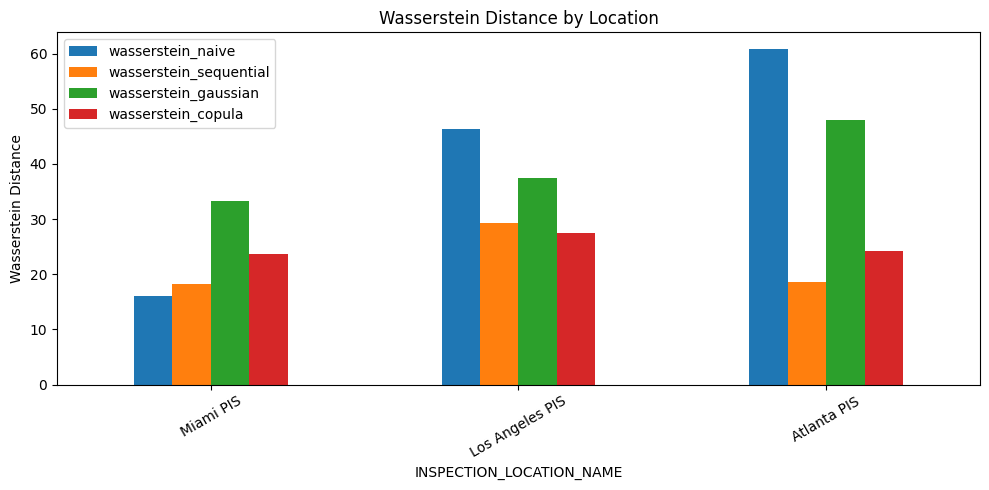

In [12]:
import matplotlib.pyplot as plt

wasserstein_df.plot(
    x='INSPECTION_LOCATION_NAME',
    y=['wasserstein_naive', 'wasserstein_sequential','wasserstein_gaussian',"wasserstein_copula"],
    kind='bar',
    figsize=(10, 5)
)
plt.ylabel('Wasserstein Distance')
plt.title('Wasserstein Distance by Location')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
# Prepare a list of unique PIS stations
pis_stations = df['INSPECTION_LOCATION_NAME'].unique()
pis_stations = ['Los Angeles PIS',  'Miami PIS', 'Atlanta PIS',]

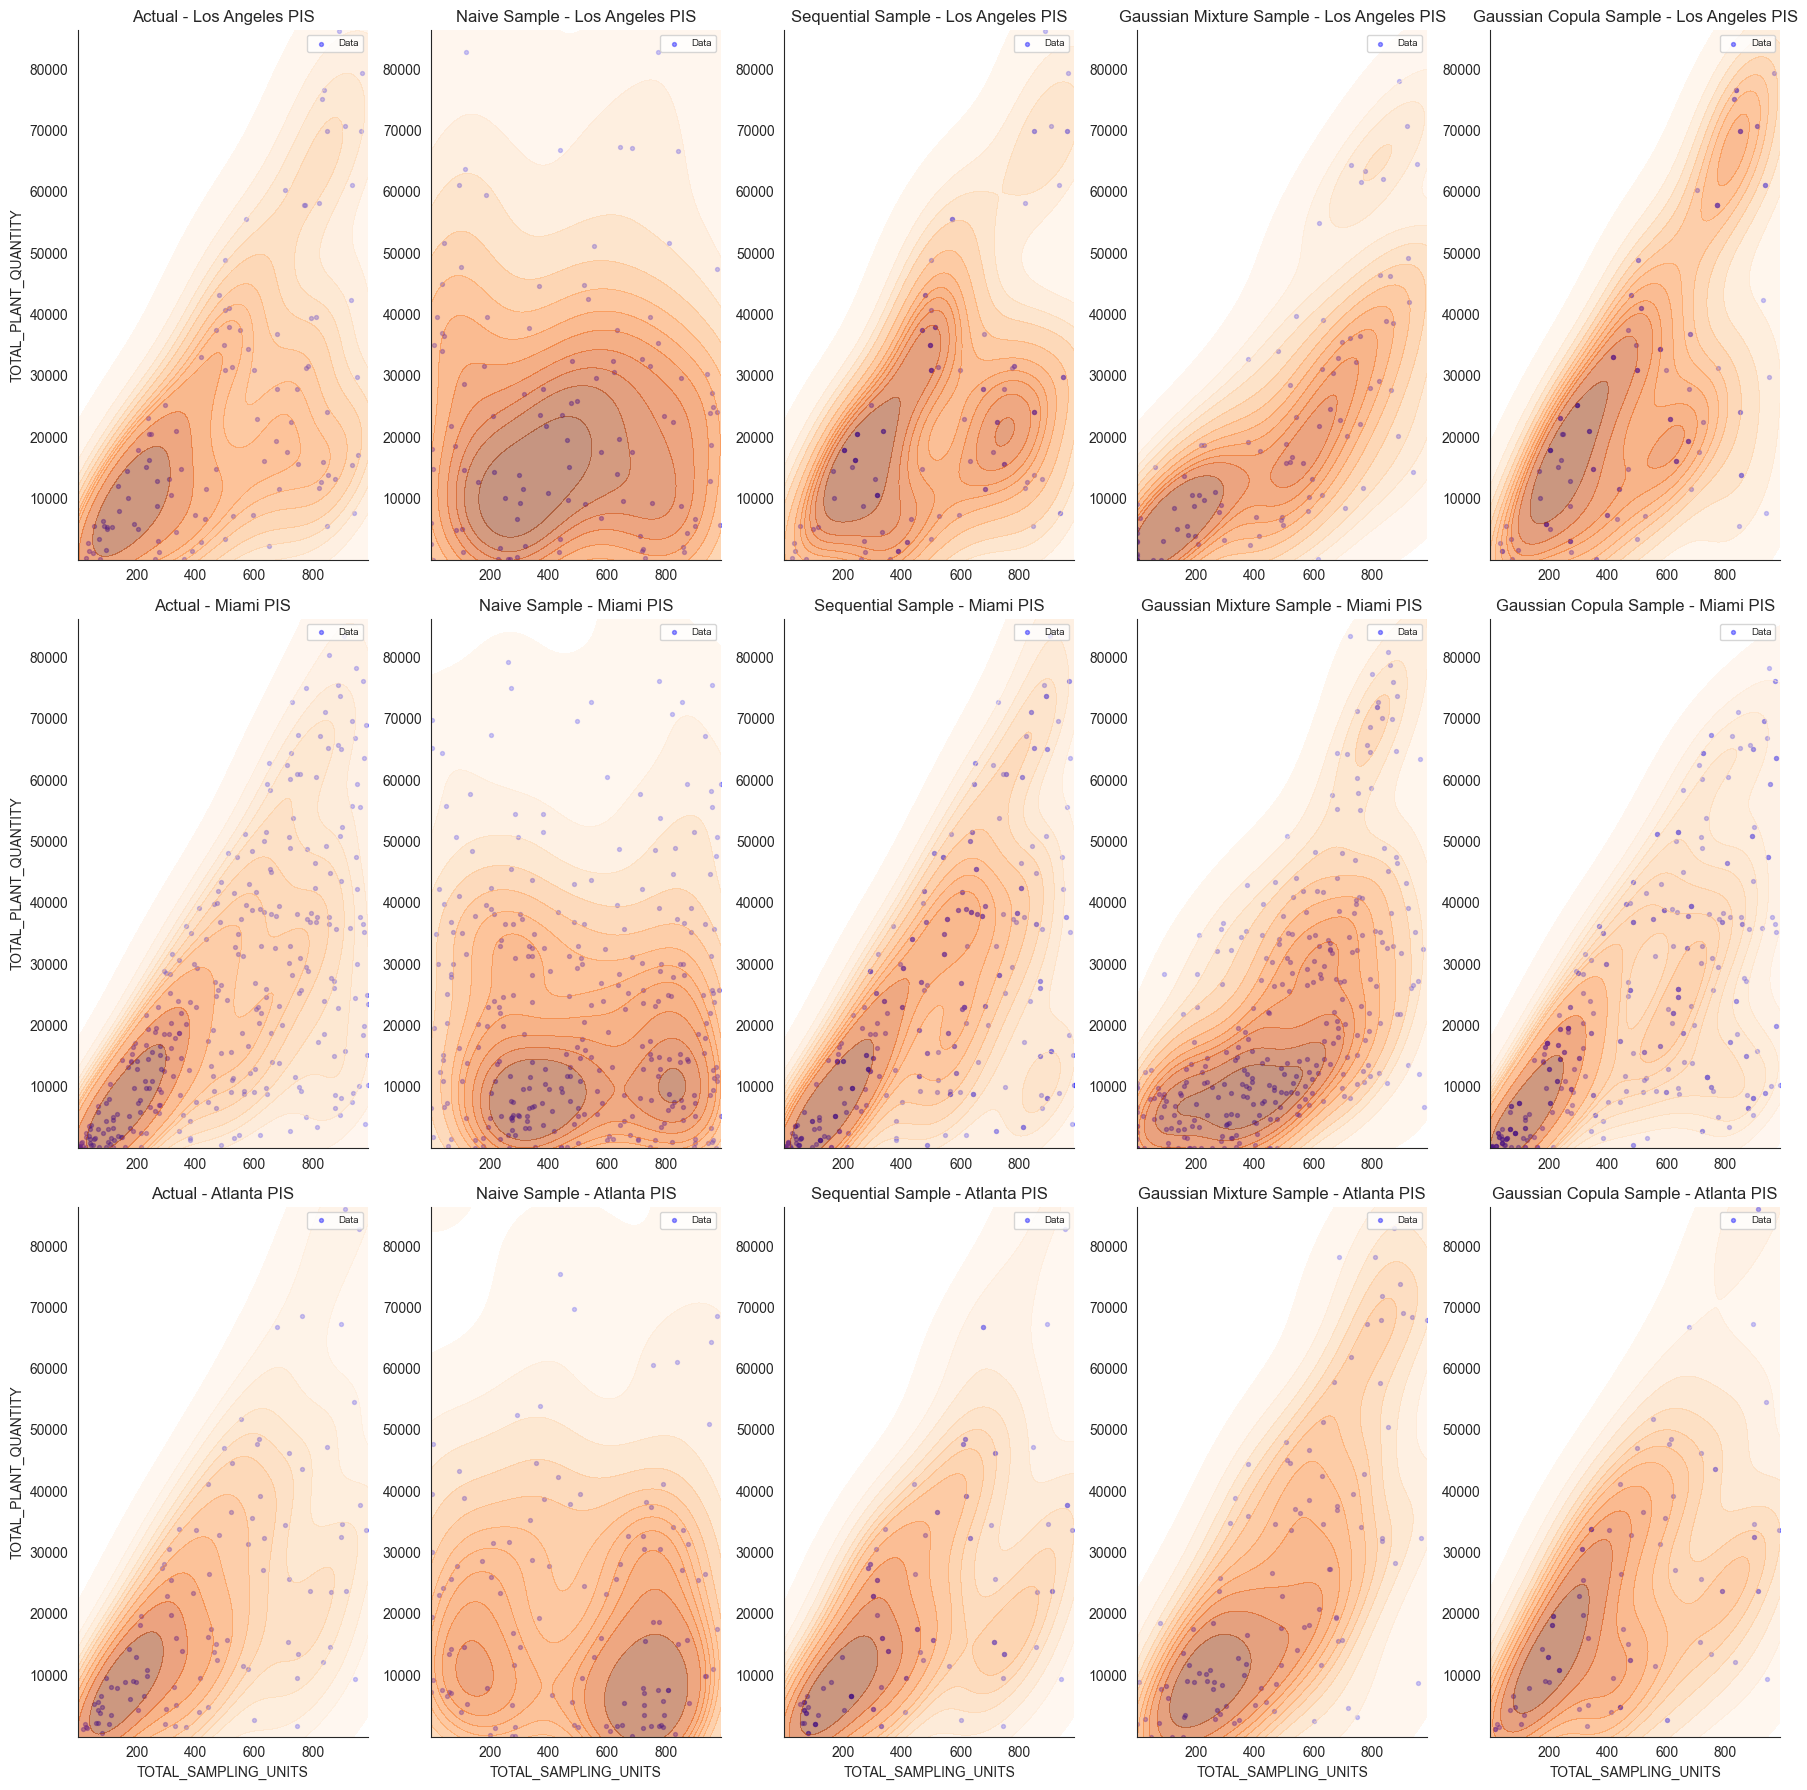

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

datasets = [
    (df, "Actual"),
    (sampled_df, "Naive Sample"),
    (sequential_sampled_df, "Sequential Sample"),
    (gmm_sampled_df, "Gaussian Mixture Sample"),
    (gc_sampled_df, "Gaussian Copula Sample"),
]

XCOL = "TOTAL_SAMPLING_UNITS"
YCOL = "TOTAL_PLANT_QUANTITY"

# Global limits (percentile-trim to avoid extreme outliers; tweak p if needed)
p_low, p_high = 0.01, 0.99
all_x, all_y = [], []
for pis in pis_stations:
    for data, _ in datasets:
        sub = data.loc[data["INSPECTION_LOCATION_NAME"] == pis, [XCOL, YCOL]].dropna()
        if not sub.empty:
            all_x.extend(sub[XCOL].tolist())
            all_y.extend(sub[YCOL].tolist())

x_min, x_max = np.quantile(all_x, [p_low, p_high])
y_min, y_max = np.quantile(all_y, [p_low, p_high])

# --- plotting
sns.set_style("white")
fig, axes = plt.subplots(len(pis_stations), len(datasets),
                         figsize=(18, 6 * len(pis_stations)))
axes = np.atleast_2d(axes)

for i, pis in enumerate(pis_stations):
    for j, (data, title) in enumerate(datasets):
        ax = axes[i, j]
        sub = data.loc[data["INSPECTION_LOCATION_NAME"] == pis, [XCOL, YCOL]].dropna()

        if sub.empty:
            ax.text(0.5, 0.5, "No data for this PIS", ha="center", va="center")
        else:
            # Scatter overlay
            ax.scatter(sub[XCOL], sub[YCOL], s=8, color="blue", alpha=0.4, label="Data")
            # KDE background
            sns.kdeplot(
                data=sub, x=XCOL, y=YCOL,
                fill=True, levels=12, thresh=0.02, cmap="Oranges", alpha=0.5, ax=ax
            )

        # Same limits for all subplots
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        ax.set_title(f"{title} - {pis}")
        if i == len(pis_stations) - 1:
            ax.set_xlabel(XCOL)
        else:
            ax.set_xlabel("")
        if j == 0:
            ax.set_ylabel(YCOL)
        else:
            ax.set_ylabel("")

        # small legend, unobtrusive
        ax.legend(loc="upper right", fontsize=7, frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

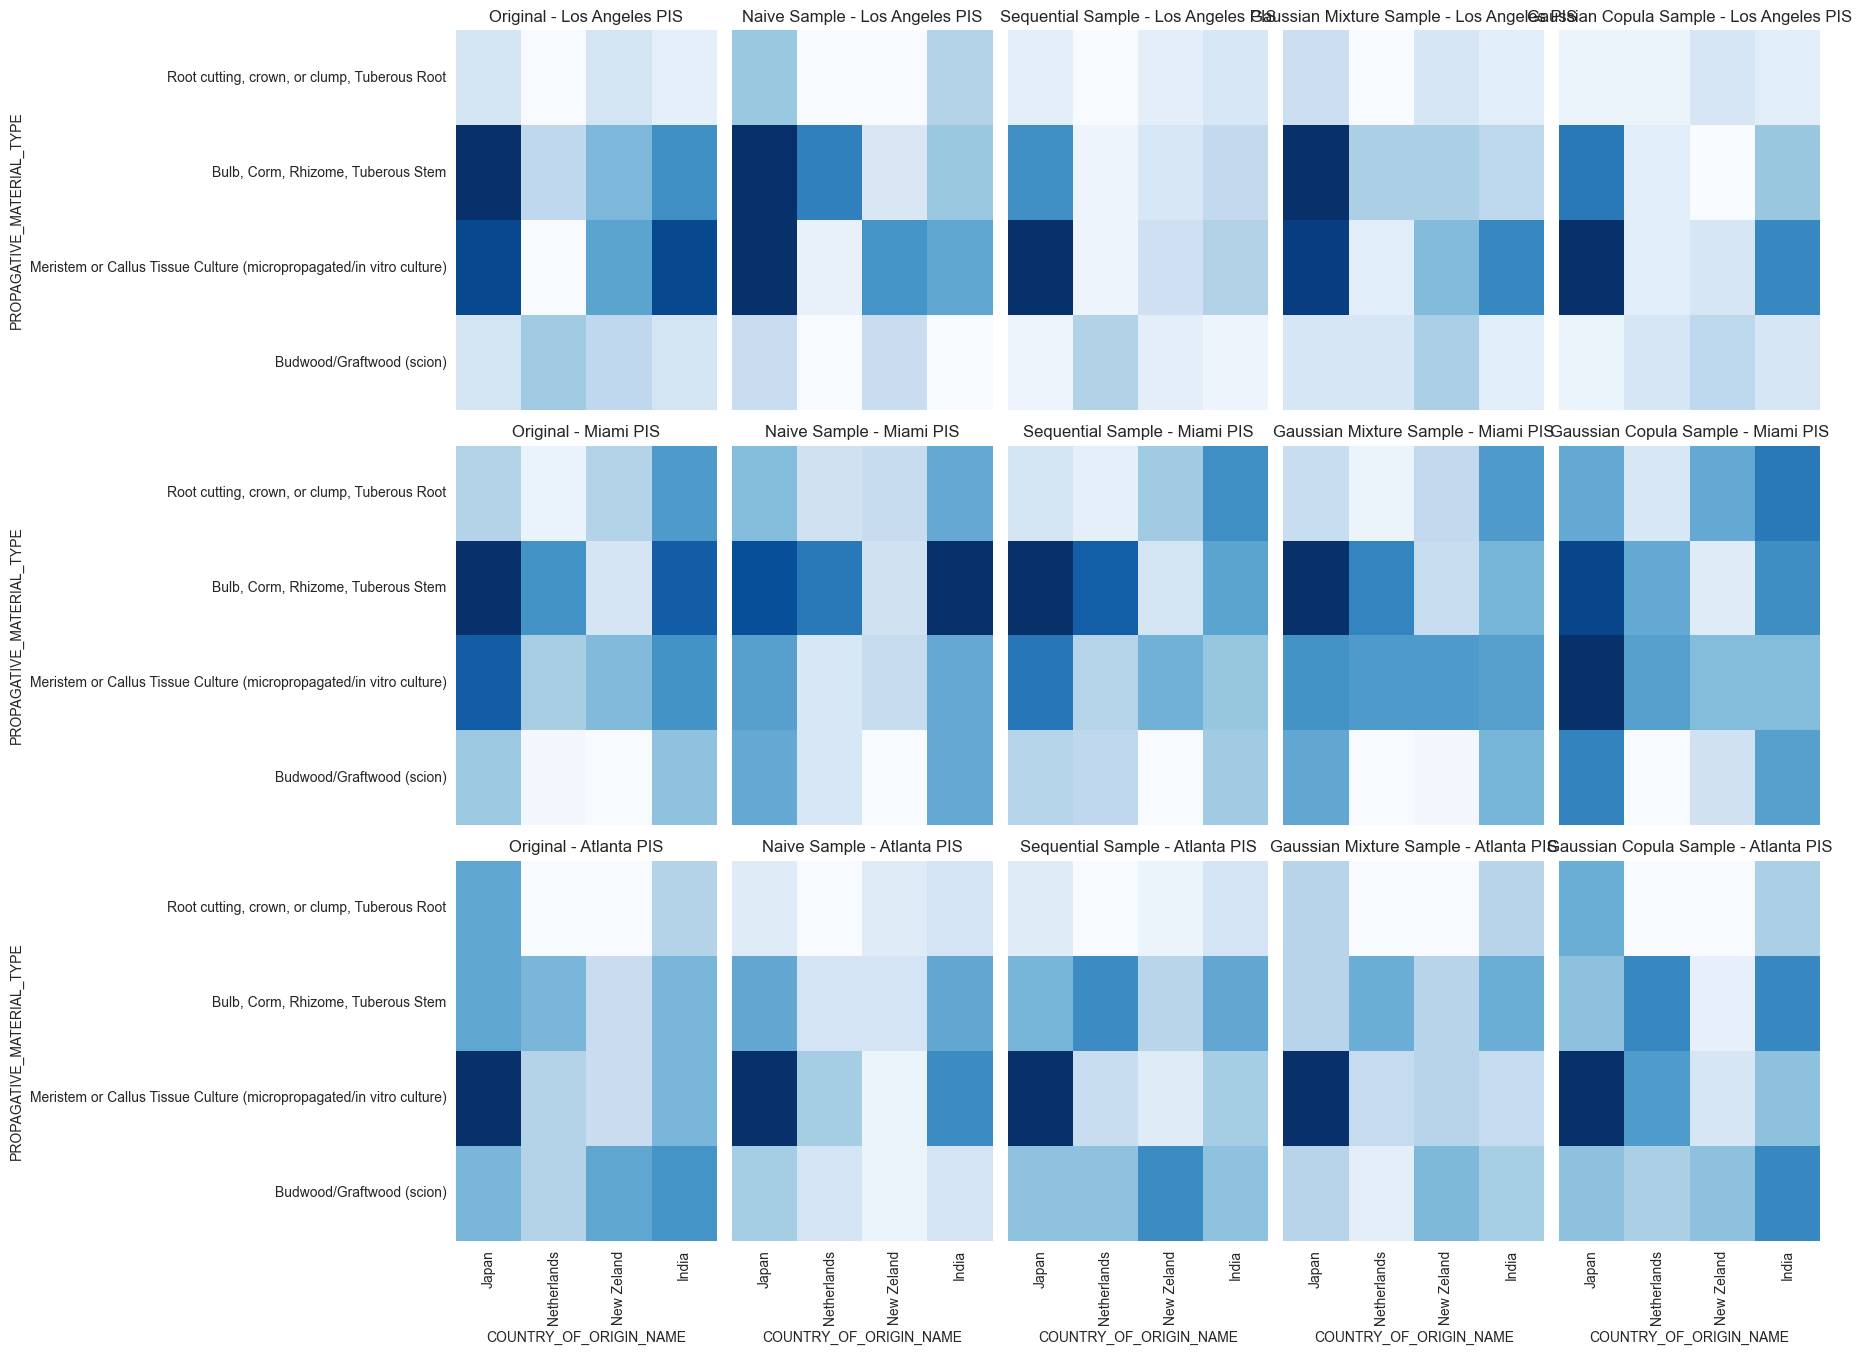

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt


datasets = [
    (df, "Original"),
    (sampled_df, "Naive Sample"),
    (sequential_sampled_df, "Sequential Sample"),
    (gmm_sampled_df, "Gaussian Mixture Sample"),
    (gc_sampled_df, "Gaussian Copula Sample"),
]

# Get all unique PROPAGATIVE_MATERIAL_TYPE and COUNTRY_OF_ORIGIN_NAME values for consistent axes
all_types = pd.unique(pd.concat([d[0]["PROPAGATIVE_MATERIAL_TYPE"] for d in datasets]).astype(str))
all_countries = pd.unique(pd.concat([d[0]["COUNTRY_OF_ORIGIN_NAME"] for d in datasets]).astype(str))

fig, axes = plt.subplots(len(pis_stations), len(datasets), 
                         figsize=(20, 5 * len(pis_stations)), sharex=True, sharey=True)

for i, pis in enumerate(pis_stations):
    for j, (data, title) in enumerate(datasets):
        ax = axes[i, j] if len(pis_stations) > 1 else axes[j]
        subset = data[data['INSPECTION_LOCATION_NAME'] == pis]
        if not subset.empty:
            # Create a pivot table of counts with all_types and all_countries for consistent axes
            pivot = subset.pivot_table(
                index="PROPAGATIVE_MATERIAL_TYPE",
                columns="COUNTRY_OF_ORIGIN_NAME",
                aggfunc="size",
                fill_value=0
            )
            # Reindex to ensure all types and countries are present in the same order
            pivot = pivot.reindex(index=all_types, columns=all_countries, fill_value=0)
            sns.heatmap(
                pivot,
                cmap="Blues",
                ax=ax,
                cbar=False
            )
        ax.set_title(f"{title} - {pis}")
        # Only set x/y labels on the outer axes for shared labels
        if i == len(pis_stations) - 1:
            ax.set_xlabel("COUNTRY_OF_ORIGIN_NAME")
        else:
            ax.set_xlabel("")
        if j == 0:
            ax.set_ylabel("PROPAGATIVE_MATERIAL_TYPE")
        else:
            ax.set_ylabel("")

# Set shared x/y labels for the whole figure
# fig.text(0.5, 0.04, 'COUNTRY_OF_ORIGIN_NAME', ha='center', va='center', fontsize=14)
# fig.text(0.06, 0.5, 'PROPAGATIVE_MATERIAL_TYPE', ha='center', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.08, 0.06, 1, 0.97])
plt.show()


In [16]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance

group_col = 'INSPECTION_LOCATION_NAME'
locations = df[group_col].dropna().unique()

calc_cols = [
    'PATHWAY',
    'COUNTRY_OF_ORIGIN_NAME',
    'PROPAGATIVE_MATERIAL_TYPE',
    'TOTAL_SAMPLING_UNITS',
    'TOTAL_PLANT_QUANTITY',
]

discrete_cols = {
    'PATHWAY',
    'COUNTRY_OF_ORIGIN_NAME',
    'PROPAGATIVE_MATERIAL_TYPE',
}

rows = []

for col in calc_cols:
    col_is_discrete = col in discrete_cols

    for loc in locations:
        orig = df.loc[df[group_col] == loc, col].dropna()
        naive = sampled_df.loc[sampled_df[group_col] == loc, col].dropna()
        seq = sequential_sampled_df.loc[sequential_sampled_df[group_col] == loc, col].dropna()
        gmm = gmm_sampled_df.loc[gmm_sampled_df[group_col] == loc, col].dropna() 
        gc = gc_sampled_df.loc[gc_sampled_df[group_col] == loc, col].dropna() 

        if len(orig) == 0:
            w_naive = w_seq = w_gmm = w_gc =  np.nan
        else:
            if col_is_discrete:
                # CATEGORICAL/OBJECT DISCRETE (uses alphabetical order to impose a metric)
                cats = pd.Index(pd.unique(pd.concat([
                    orig.astype("string"),
                    naive.astype("string"),
                    seq.astype("string"),
                    gmm.astype("string"),
                    gc.astype("string"),
                ]))).sort_values()

                enc = lambda s: pd.Categorical(s.astype("string"), categories=cats, ordered=True).codes
                oa, on, os, og, oh = map(enc, (orig, naive, seq, gmm, gc))

                # turn to supports + weights
                va, vn, vs, vg, vh = map(pd.Series, (oa, on, os, og, oh))
                sa, wa = va.value_counts().sort_index().index.to_numpy(), va.value_counts().sort_index().values.astype(float)
                sn, wn = vn.value_counts().sort_index().index.to_numpy(), vn.value_counts().sort_index().values.astype(float)
                ss, ws = vs.value_counts().sort_index().index.to_numpy(), vs.value_counts().sort_index().values.astype(float)
                sg, wg = vg.value_counts().sort_index().index.to_numpy(), vg.value_counts().sort_index().values.astype(float)
                sh, wh = vh.value_counts().sort_index().index.to_numpy(), vh.value_counts().sort_index().values.astype(float)

                w_naive = wasserstein_distance(sa, sn, u_weights=wa, v_weights=wn) if len(naive) else np.nan
                w_seq   = wasserstein_distance(sa, ss, u_weights=wa, v_weights=ws) if len(seq) else np.nan
                w_gmm   = wasserstein_distance(sa, sg, u_weights=wa, v_weights=wg) if len(gmm) else np.nan
                w_gc   = wasserstein_distance(sa, sh, u_weights=wa, v_weights=wh) if len(gc) else np.nan

            else:
                # CONTINUOUS
                tofloat = lambda s: s.astype(float).to_numpy()
                oa = tofloat(orig)
                w_naive = wasserstein_distance(oa, tofloat(naive)) if len(naive) else np.nan
                w_seq   = wasserstein_distance(oa, tofloat(seq))   if len(seq) else np.nan
                w_gmm   = wasserstein_distance(oa, tofloat(gmm))   if len(gmm) else np.nan
                w_gc   = wasserstein_distance(oa, tofloat(gc))   if len(gc) else np.nan

        rows.append({
            group_col: loc,
            'column': col,
            'is_discrete': col_is_discrete,
            'wasserstein_naive': w_naive,
            'wasserstein_sequential': w_seq,
            'wasserstein_gaussian': w_gmm,
            'wasserstein_copula': w_gc,
        })

wasserstein_df = pd.DataFrame(rows)
wasserstein_df


,INSPECTION_LOCATION_NAME,column,is_discrete,wasserstein_naive,wasserstein_sequential,wasserstein_gaussian,wasserstein_copula
0,Miami PIS,PATHWAY,True,0.073069,0.033781,0.055408,0.048271
1,Los Angeles PIS,PATHWAY,True,0.170476,0.030000,0.055052,0.090370
2,Atlanta PIS,PATHWAY,True,0.421622,0.080000,0.062308,0.005000
3,Miami PIS,COUNTRY_OF_ORIGIN_NAME,True,0.028334,0.101946,0.066194,0.086818
4,Los Angeles PIS,COUNTRY_OF_ORIGIN_NAME,True,0.110000,0.140000,0.105876,0.146296
5,Atlanta PIS,COUNTRY_OF_ORIGIN_NAME,True,0.095856,0.110000,0.058077,0.115000
6,Miami PIS,PROPAGATIVE_MATERIAL_TYPE,True,0.112936,0.030917,0.031907,0.108437
7,Los Angeles PIS,PROPAGATIVE_MATERIAL_TYPE,True,0.132857,0.090000,0.107732,0.080741
8,Atlanta PIS,PROPAGATIVE_MATERIAL_TYPE,True,0.188198,0.220000,0.105385,0.040000
9,Miami PIS,TOTAL_SAMPLING_UNITS,False,16.079970,18.234161,33.210691,23.646145


<Figure size 1000x1000 with 0 Axes>

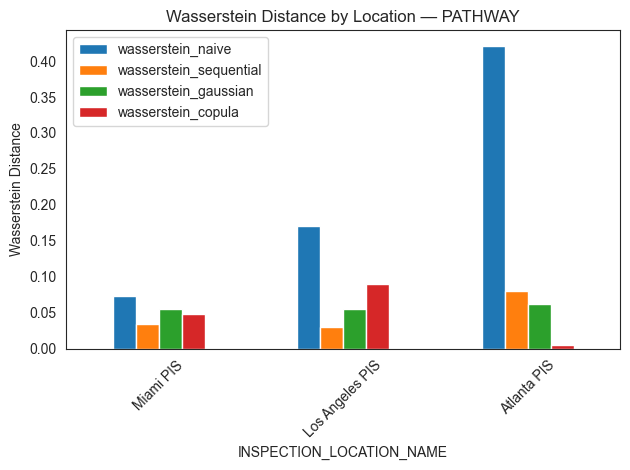

<Figure size 1000x1000 with 0 Axes>

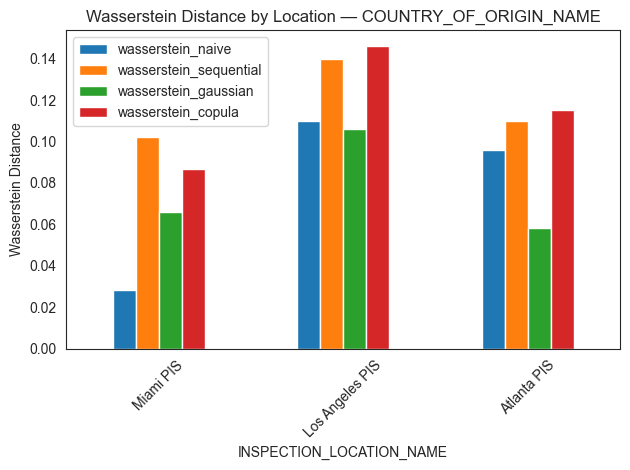

<Figure size 1000x1000 with 0 Axes>

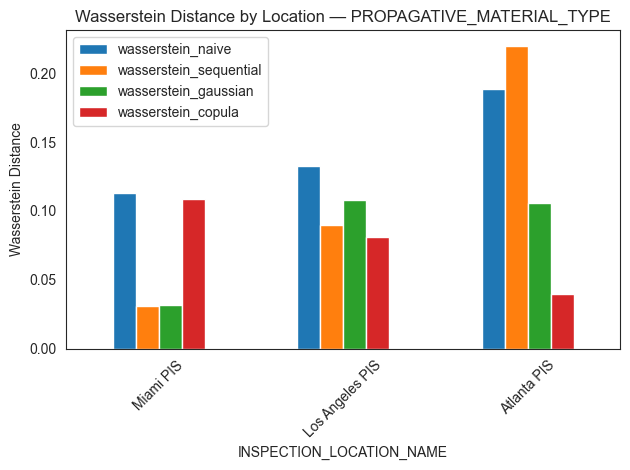

<Figure size 1000x1000 with 0 Axes>

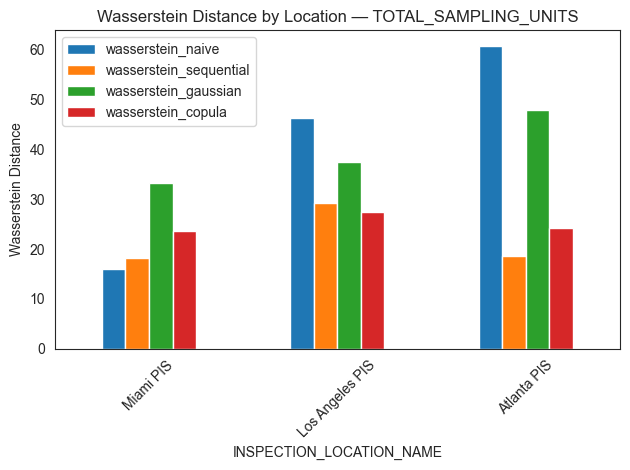

<Figure size 1000x1000 with 0 Axes>

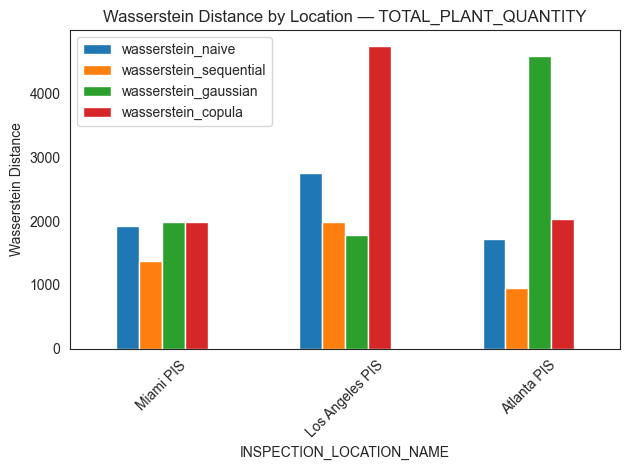

In [17]:
import matplotlib.pyplot as plt

# unique variables (your "column" field in wasserstein_df)
vars_ = wasserstein_df['column'].unique()

for var in vars_:
    sub = wasserstein_df[wasserstein_df['column'] == var]

    plt.figure(figsize=(10, 10))
    sub.plot(
        x='INSPECTION_LOCATION_NAME',
        y=['wasserstein_naive', 'wasserstein_sequential', 'wasserstein_gaussian','wasserstein_copula'],
        kind='bar',
    )
    plt.ylabel('Wasserstein Distance')
    plt.title(f'Wasserstein Distance by Location — {var}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()